# RiNALMo on real short ncRNA predictions (hg38 vs mm39)

Take real CURIA pipeline predictions for human-to-mouse short ncRNAs.
For each: get the human reference sequence, get the mouse query region + flanks,
slide the reference embedding through the query embedding, and check if RiNALMo
finds the right position.

Compare to the pipeline's RNA-FM-based MMD scores.

In [1]:
import sys, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "modules" / "RiNALMo"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "RNA-FM"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "pipeline"))

import short_ncrna as sn
from pyrion import TwoBitAccessor
from pyrion.io.bed import read_bed12_file

SEED = 42
random.seed(SEED); np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)

from rinalmo.pretrained import get_pretrained_model
rin_model, rin_alpha = get_pretrained_model(model_name="giga-v1")
rin_model = rin_model.to(device).eval()

def emb(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    tokens = torch.tensor(
        rin_alpha.batch_tokenize([rna]), dtype=torch.int64, device=device
    )
    with torch.no_grad():
        out = rin_model(tokens)
    return out["representation"][0, 1:1 + len(rna), :].cpu().float().numpy()

print(f"RiNALMo loaded on {device}")

RiNALMo loaded on mps


## Load predictions + reference data

In [2]:
# Load pipeline predictions
pred_path = REPO_ROOT / "preprint_results" / "hg38_vs_mm39" / "short_ncRNA_details.tsv"
preds = pd.read_csv(pred_path, sep="\t")
print(f"Total predictions: {len(preds)}")
print(preds["biotype"].value_counts().to_string())

# Load reference annotations
hg38_bed_path = REPO_ROOT / "input_data" / "reference_annotation" / "hg38.input.w.tRNA.bed"
hg38_2bit = TwoBitAccessor(str(REPO_ROOT / "input_data" / "2bit" / "hg38.2bit"))
mm39_2bit = TwoBitAccessor(str(REPO_ROOT / "input_data" / "2bit" / "mm39.2bit"))

hg38_bed = read_bed12_file(str(hg38_bed_path))
hg38_tx = {t.id: t for t in hg38_bed}

# Also load primary BED for ENST lookups
hg38_primary_bed = read_bed12_file(str(REPO_ROOT / "input_data" / "reference_annotation" / "hg38.primary_only.bed"))
for t in hg38_primary_bed:
    if t.id not in hg38_tx:
        hg38_tx[t.id] = t

# Load metadata to map gene_id -> transcript_id
meta = pd.read_csv(REPO_ROOT / "input_data" / "reference_annotation" / "hg38.primary_only.transcript_metadata.tsv", sep="\t")
gene_to_tx = dict(zip(meta["gene_id"], meta["transcript_id"]))

print(f"\nReference transcripts: {len(hg38_tx)}")
print(f"Gene-to-transcript mappings: {len(gene_to_tx)}")

Total predictions: 2806
biotype
miRNA              1278
snoRNA              447
snRNA               350
misc_RNA            267
tRNA                255
rRNA_pseudogene     145
lncRNA               36
scaRNA               15
sRNA                  7
rRNA                  3
ribozyme              2
vault_RNA             1

Reference transcripts: 386300
Gene-to-transcript mappings: 79317


In [3]:
# Sample ~50 predictions across biotypes (manageable on MacBook)
# Focus on core biotypes with good coverage
SAMPLE_PER_BIOTYPE = {"miRNA": 15, "tRNA": 10, "snoRNA": 10, "snRNA": 5, "misc_RNA": 5}
FLANK_FRAC = 0.15  # 15% extra on each side (matching pipeline default ~10%)

comp = {"A": "U", "T": "A", "G": "C", "C": "G", "N": "N"}

def revcomp(seq):
    return "".join(comp.get(b, "N") for b in reversed(seq.upper())).replace("T", "U")

def get_ref_seq(gene_id):
    """Get human reference RNA sequence for a gene_id."""
    # tRNAs: gene_id is directly the BED ID
    if gene_id in hg38_tx:
        return sn._get_spliced_sequence(hg38_tx[gene_id], hg38_2bit)
    # ENSG genes: look up transcript
    tx_id = gene_to_tx.get(gene_id)
    if tx_id and tx_id in hg38_tx:
        return sn._get_spliced_sequence(hg38_tx[tx_id], hg38_2bit)
    return None

def get_query_seq_with_flanks(row, flank_frac=FLANK_FRAC):
    """Get mouse query sequence with flanks from prediction coordinates."""
    chrom, start, end, strand = row["chrom"], row["start"], row["end"], row["strand"]
    length = end - start
    flank = max(10, int(length * flank_frac))
    ext_start = max(0, start - flank)
    ext_end = end + flank
    try:
        seq = str(mm39_2bit.fetch(chrom, ext_start, ext_end)).upper()
    except:
        return None, 0, 0
    if strand == "-":
        seq = revcomp(seq)
        core_start = flank  # after revcomp, core is still in the middle
    else:
        seq = seq.replace("T", "U")
        core_start = start - ext_start
    core_end = core_start + length
    return seq, core_start, core_end

# Sample predictions
sampled = []
rng = random.Random(SEED)
for bt, n in SAMPLE_PER_BIOTYPE.items():
    bt_preds = preds[preds.biotype == bt]
    chosen = bt_preds.sample(n=min(n, len(bt_preds)), random_state=SEED)
    for _, row in chosen.iterrows():
        ref_seq = get_ref_seq(row["gene_id"])
        if ref_seq is None:
            continue
        ref_seq = ref_seq.upper().replace("T", "U")
        query_seq, core_start, core_end = get_query_seq_with_flanks(row)
        if query_seq is None or "N" in query_seq or "N" in ref_seq:
            continue
        if len(ref_seq) < 20 or len(query_seq) < len(ref_seq):
            continue
        sampled.append({
            "gene_id": row["gene_id"], "biotype": row["biotype"],
            "pipeline_mmd": row["mmd_score"],
            "ref_seq": ref_seq, "ref_len": len(ref_seq),
            "query_seq": query_seq, "query_len": len(query_seq),
            "core_start": core_start, "core_end": core_end,
        })

sampled_df = pd.DataFrame(sampled)
print(f"Sampled {len(sampled_df)} predictions:")
print(sampled_df["biotype"].value_counts().to_string())
print(f"\nRef lengths: {sampled_df['ref_len'].min()}-{sampled_df['ref_len'].max()} nt")
print(f"Query lengths: {sampled_df['query_len'].min()}-{sampled_df['query_len'].max()} nt")

Sampled 45 predictions:
biotype
miRNA       15
tRNA        10
snoRNA      10
snRNA        5
misc_RNA     5

Ref lengths: 44-135 nt
Query lengths: 64-176 nt


## RiNALMo findability on real predictions

For each prediction: embed reference standalone, embed query once, slide
reference-length window through query, find MMD minimum.

In [4]:
results = []

for idx, row in sampled_df.iterrows():
    ref_emb = emb(row["ref_seq"])
    query_emb = emb(row["query_seq"])
    ref_len = row["ref_len"]
    n_windows = len(query_emb) - ref_len + 1

    if n_windows <= 0:
        continue

    # Slide
    mmd_profile = np.array([sn._compute_mmd(ref_emb, query_emb[i:i+ref_len])
                            for i in range(n_windows)])
    best_pos = int(np.argmin(mmd_profile))
    best_mmd = mmd_profile[best_pos]
    mmd_at_core = mmd_profile[row["core_start"]] if row["core_start"] < n_windows else float("nan")
    offset = best_pos - row["core_start"]

    results.append({
        **row.to_dict(),
        "rinalmo_best_pos": best_pos,
        "rinalmo_best_mmd": best_mmd,
        "rinalmo_mmd_at_core": mmd_at_core,
        "offset": offset,
    })
    if (len(results)) % 10 == 0:
        print(f"  {len(results)}/{len(sampled_df)} done")

res_df = pd.DataFrame(results)
print(f"\nProcessed {len(res_df)} predictions")

  10/45 done
  20/45 done
  30/45 done
  40/45 done

Processed 45 predictions


In [5]:
# Summary by biotype
print("Offset from expected core position (|offset| <= 5 = OK):\n")
for bt in SAMPLE_PER_BIOTYPE:
    sub = res_df[res_df.biotype == bt]
    if len(sub) == 0:
        continue
    n_ok = (sub["offset"].abs() <= 5).sum()
    print(f"  {bt:>10s}: {n_ok}/{len(sub)} found within 5 nt  "
          f"(median |off|={sub['offset'].abs().median():.0f}, "
          f"mean MMD={sub['rinalmo_best_mmd'].mean():.4f})")

print(f"\n  {'TOTAL':>10s}: {(res_df['offset'].abs() <= 5).sum()}/{len(res_df)} found within 5 nt")

Offset from expected core position (|offset| <= 5 = OK):

       miRNA: 6/15 found within 5 nt  (median |off|=7, mean MMD=0.0707)
        tRNA: 1/10 found within 5 nt  (median |off|=10, mean MMD=0.0049)
      snoRNA: 4/10 found within 5 nt  (median |off|=6, mean MMD=0.0585)
       snRNA: 4/5 found within 5 nt  (median |off|=4, mean MMD=0.1058)
    misc_RNA: 1/5 found within 5 nt  (median |off|=11, mean MMD=0.0836)

       TOTAL: 16/45 found within 5 nt


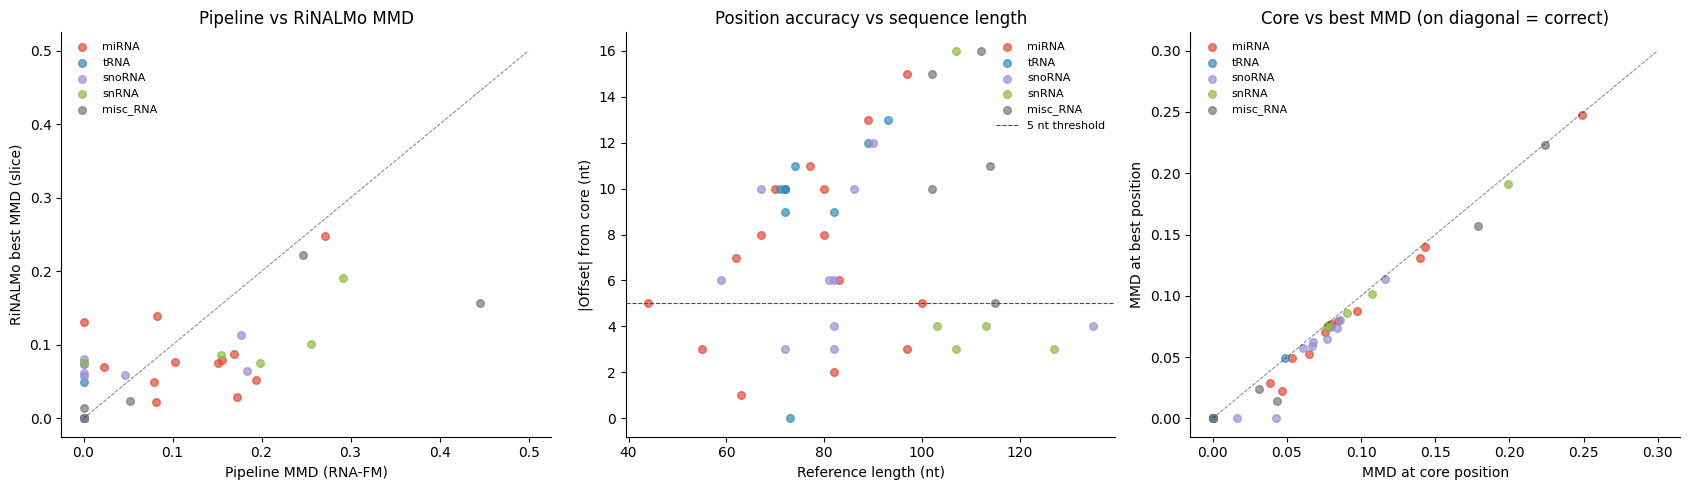

In [6]:
# Scatter: pipeline MMD vs RiNALMo MMD
bt_colors = {"miRNA": "#e24a33", "tRNA": "#348abd", "snoRNA": "#988ed5",
             "snRNA": "#8eba42", "misc_RNA": "#777777"}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: pipeline MMD vs RiNALMo MMD
ax = axes[0]
for bt in SAMPLE_PER_BIOTYPE:
    sub = res_df[res_df.biotype == bt]
    ax.scatter(sub["pipeline_mmd"], sub["rinalmo_best_mmd"],
              c=bt_colors.get(bt, "grey"), label=bt, s=30, alpha=0.7)
ax.plot([0, 0.5], [0, 0.5], "k--", lw=0.7, alpha=0.5)
ax.set_xlabel("Pipeline MMD (RNA-FM)")
ax.set_ylabel("RiNALMo best MMD (slice)")
ax.set_title("Pipeline vs RiNALMo MMD")
ax.legend(fontsize=8, frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Panel 2: offset distribution
ax = axes[1]
for bt in SAMPLE_PER_BIOTYPE:
    sub = res_df[res_df.biotype == bt]
    ax.scatter(sub["ref_len"], sub["offset"].abs(),
              c=bt_colors.get(bt, "grey"), label=bt, s=30, alpha=0.7)
ax.axhline(5, color="green", ls="--", lw=0.8, label="5 nt threshold")
ax.set_xlabel("Reference length (nt)")
ax.set_ylabel("|Offset| from core (nt)")
ax.set_title("Position accuracy vs sequence length")
ax.legend(fontsize=8, frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Panel 3: RiNALMo MMD at best vs at core position
ax = axes[2]
for bt in SAMPLE_PER_BIOTYPE:
    sub = res_df[res_df.biotype == bt]
    ax.scatter(sub["rinalmo_mmd_at_core"], sub["rinalmo_best_mmd"],
              c=bt_colors.get(bt, "grey"), label=bt, s=30, alpha=0.7)
ax.plot([0, 0.3], [0, 0.3], "k--", lw=0.7, alpha=0.5)
ax.set_xlabel("MMD at core position")
ax.set_ylabel("MMD at best position")
ax.set_title("Core vs best MMD (on diagonal = correct)")
ax.legend(fontsize=8, frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
# Detailed table
show_cols = ["gene_id", "biotype", "ref_len", "query_len",
             "pipeline_mmd", "rinalmo_best_mmd", "offset"]
print(res_df[show_cols].sort_values("biotype").to_string(index=False, float_format="{:.4f}".format))

          gene_id  biotype  ref_len  query_len  pipeline_mmd  rinalmo_best_mmd  offset
ENSG00000284040.1    miRNA       80        104        0.0000            0.0000      -8
ENSG00000207551.1    miRNA      100        127        0.1724            0.0292      -5
ENSG00000284436.1    miRNA       62         80        0.0819            0.0220      -7
ENSG00000284253.1    miRNA       44         64        0.0000            0.1305      -5
ENSG00000275259.1    miRNA       67         87        0.1693            0.0874       8
ENSG00000207646.1    miRNA       97        119        0.1022            0.0767       3
ENSG00000274115.1    miRNA       97        131        0.1934            0.0524     -15
ENSG00000263858.1    miRNA       77         97        0.1554            0.0797     -11
ENSG00000265846.1    miRNA       70         91        0.1512            0.0756     -10
ENSG00000221445.3    miRNA       82        100        0.0230            0.0701       2
ENSG00000207989.3    miRNA       89        

## Summary

In [8]:
print("=" * 70)
print("RINALMO vs PIPELINE ON REAL hg38->mm39 PREDICTIONS")
print("=" * 70)

n_total = len(res_df)
n_found = (res_df["offset"].abs() <= 5).sum()
n_close = (res_df["offset"].abs() <= 10).sum()

print(f"\nTotal predictions tested: {n_total}")
print(f"Found within 5 nt:  {n_found}/{n_total} ({n_found/n_total:.0%})")
print(f"Found within 10 nt: {n_close}/{n_total} ({n_close/n_total:.0%})")

print(f"\nPipeline MMD (RNA-FM, re-embed):  mean={res_df['pipeline_mmd'].mean():.4f}")
print(f"RiNALMo MMD (slice from long):    mean={res_df['rinalmo_best_mmd'].mean():.4f}")

print("\nPer biotype:")
for bt in SAMPLE_PER_BIOTYPE:
    sub = res_df[res_df.biotype == bt]
    if len(sub) == 0:
        continue
    n_ok = (sub["offset"].abs() <= 5).sum()
    print(f"  {bt:>10s}: {n_ok:>2d}/{len(sub)} within 5nt, "
          f"pipeline={sub['pipeline_mmd'].mean():.3f}, "
          f"rinalmo={sub['rinalmo_best_mmd'].mean():.3f}")

RINALMO vs PIPELINE ON REAL hg38->mm39 PREDICTIONS

Total predictions tested: 45
Found within 5 nt:  16/45 (36%)
Found within 10 nt: 34/45 (76%)

Pipeline MMD (RNA-FM, re-embed):  mean=0.0785
RiNALMo MMD (slice from long):    mean=0.0587

Per biotype:
       miRNA:  6/15 within 5nt, pipeline=0.099, rinalmo=0.071
        tRNA:  1/10 within 5nt, pipeline=0.000, rinalmo=0.005
      snoRNA:  4/10 within 5nt, pipeline=0.041, rinalmo=0.058
       snRNA:  4/5 within 5nt, pipeline=0.180, rinalmo=0.106
    misc_RNA:  1/5 within 5nt, pipeline=0.149, rinalmo=0.084
